# MATH/CSCI 485 — Assignment #3: Image Compression via Block-wise SVD

**Author:** [Ashish Dixit]  
**Course:** MATH/CSCI 485  


---

## Overview

This notebook explores Singular Value Decomposition (SVD) as a technique for compressing grayscale images.  
The approach:
1. Divide the image into non-overlapping 8×8 blocks.
2. Apply SVD to each block and reconstruct using only the top-k singular values.
3. Analyze the trade-off between compression ratio and reconstruction quality as k varies from 1 to 8.

### Mathematical Background

Given a matrix $A \in \mathbb{R}^{m \times n}$, SVD factorizes it as:
$$A = U \Sigma V^T$$
where $U \in \mathbb{R}^{m \times m}$ and $V \in \mathbb{R}^{n \times n}$ are orthogonal matrices, and $\Sigma$ is diagonal with non-negative singular values $\sigma_1 \geq \sigma_2 \geq \dots \geq 0$.

The rank-k approximation is:
$$A_k = \sum_{i=1}^{k} \sigma_i \mathbf{u}_i \mathbf{v}_i^T$$

By the Eckart–Young theorem, $A_k$ is the best rank-k approximation of $A$ in both the Frobenius and spectral norms.

### Compression Ratio

For an $8 \times 8$ block:
- Original: 64 values
- Retained with top-k SVD: $k \times (8 + 1 + 8) = 17k$ values  
  *(k columns of U, k singular values, k rows of $V^T$)*

$$\text{Compression Ratio} = \frac{64}{17k}$$


## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image, ImageDraw
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('All packages loaded successfully.')

All packages loaded successfully.


## 2. Load and Preprocess the Image

We use a real **portrait photograph** (512×512 grayscale). The image is center-cropped to a square, then resized to 512×512 to ensure both dimensions are divisible by 8.

Portrait photos are an interesting test case because they contain:
- **Smooth, low-frequency regions** (skin tones, blurred background/bokeh)
- **Sharp edges** (hair, clothing boundary)

This mix makes them well-suited for SVD compression — the dominant singular values capture smooth gradients very efficiently.

Image shape: (512, 512), range: [0, 237]


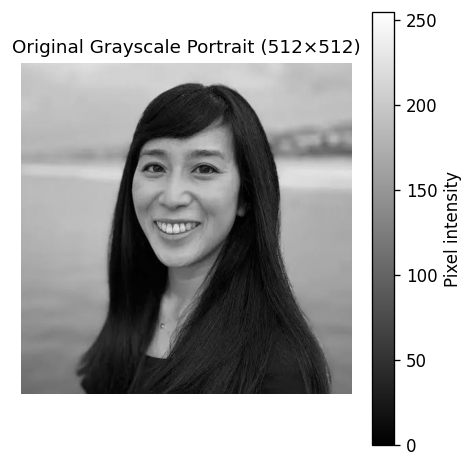

In [2]:
# Load the uploaded portrait photo
from PIL import Image
import numpy as np

# Load, convert to grayscale, crop to square, resize to 512x512
img = Image.open('Author.jpg')   
gray_pil = img.convert('L')
w, h = gray_pil.size
min_dim = min(w, h)
left, top = (w - min_dim) // 2, (h - min_dim) // 2
gray_pil = gray_pil.crop((left, top, left + min_dim, top + min_dim))
gray_pil = gray_pil.resize((512, 512), Image.LANCZOS)
gray = np.array(gray_pil, dtype=np.float64)

print(f'Image shape: {gray.shape}, range: [{gray.min():.0f}, {gray.max():.0f}]')

plt.figure(figsize=(4, 4))
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title('Original Grayscale Portrait (512×512)', fontsize=11)
plt.colorbar(label='Pixel intensity')
plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Core SVD Compression Functions

In [8]:
def compress_block(block, k):

    U, s, Vt = np.linalg.svd(block, full_matrices=False)
    # Keep only the top-k components
    recon = (U[:, :k] * s[:k]) @ Vt[:k, :]
    return recon


def compress_image(gray, k, block_size=8):

    h, w = gray.shape
    out = np.zeros_like(gray)
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = gray[i:i+block_size, j:j+block_size]
            out[i:i+block_size, j:j+block_size] = compress_block(block, k)
    return np.clip(out, 0, 255)


def compression_ratio(block_size, k):   
    original = block_size ** 2
    retained = k * (block_size + block_size + 1)   # U: bs×k, Σ: k, Vt: k×bs
    return original / retained


def frobenius_error(original, reconstructed):
    return np.linalg.norm(original - reconstructed, 'fro')


def psnr(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(255.0**2 / mse)

print('Functions defined.')

Functions defined.


## 4. Run Compression for k = 1 … 8

In [4]:
k_values   = list(range(1, 9))
ratios     = []
errors     = []
psnr_vals  = []
compressed = {}

for k in k_values:
    img_k = compress_image(gray, k, block_size=8)
    compressed[k] = img_k
    ratios.append(compression_ratio(8, k))
    errors.append(frobenius_error(gray, img_k))
    psnr_vals.append(psnr(gray, img_k))

# Display summary table
print(f'  k | Ratio    | Fro Error  | PSNR (dB)  | Quality')
print('─' * 55)
for i, k in enumerate(k_values):
    q = ('Poor'       if psnr_vals[i] < 25 else
         'Acceptable' if psnr_vals[i] < 30 else
         'Good'       if psnr_vals[i] < 35 else 'Excellent')
    print(f'  {k} | {ratios[i]:7.3f}x | {errors[i]:10.1f} | {psnr_vals[i]:10.2f} | {q}')

  k | Ratio    | Fro Error  | PSNR (dB)  | Quality
───────────────────────────────────────────────────────
  1 |   3.765x |     2617.5 |      33.96 | Good
  2 |   1.882x |     1424.5 |      39.24 | Excellent
  3 |   1.255x |      798.0 |      44.28 | Excellent
  4 |   0.941x |      436.9 |      49.51 | Excellent
  5 |   0.753x |      205.9 |      56.04 | Excellent
  6 |   0.627x |       78.4 |      64.43 | Excellent
  7 |   0.538x |       19.5 |      76.52 | Excellent
  8 |   0.471x |        0.0 |     300.42 | Excellent


## 5. Visual Results — Reconstructed Images

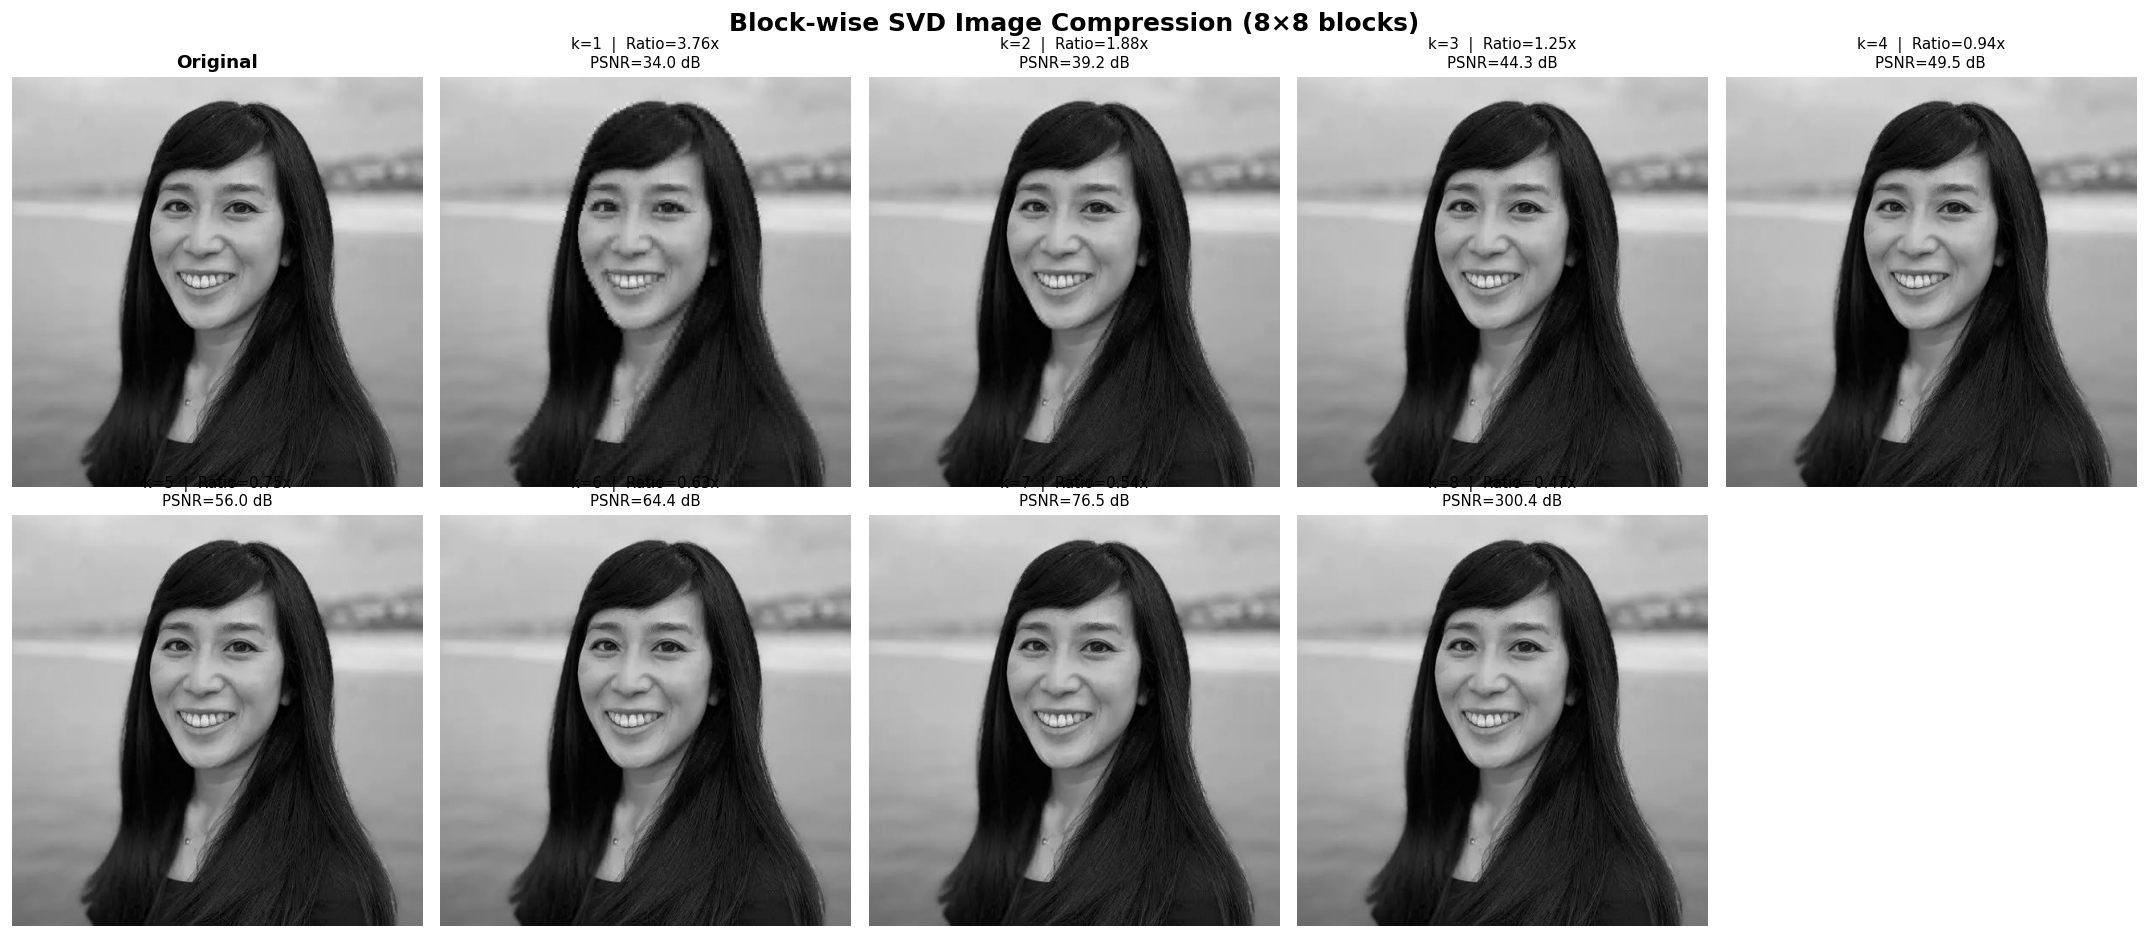

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Block-wise SVD Image Compression (8×8 blocks)', fontsize=15, fontweight='bold')

axes[0, 0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3)]
for idx, k in enumerate(k_values):
    r, c = positions[idx]
    axes[r, c].imshow(compressed[k], cmap='gray', vmin=0, vmax=255)
    axes[r, c].set_title(f'k={k}  |  Ratio={ratios[idx]:.2f}x\nPSNR={psnr_vals[idx]:.1f} dB', fontsize=9)
    axes[r, c].axis('off')

axes[1, 4].axis('off')
plt.tight_layout()
plt.show()

## 6. Compression Analysis Plots

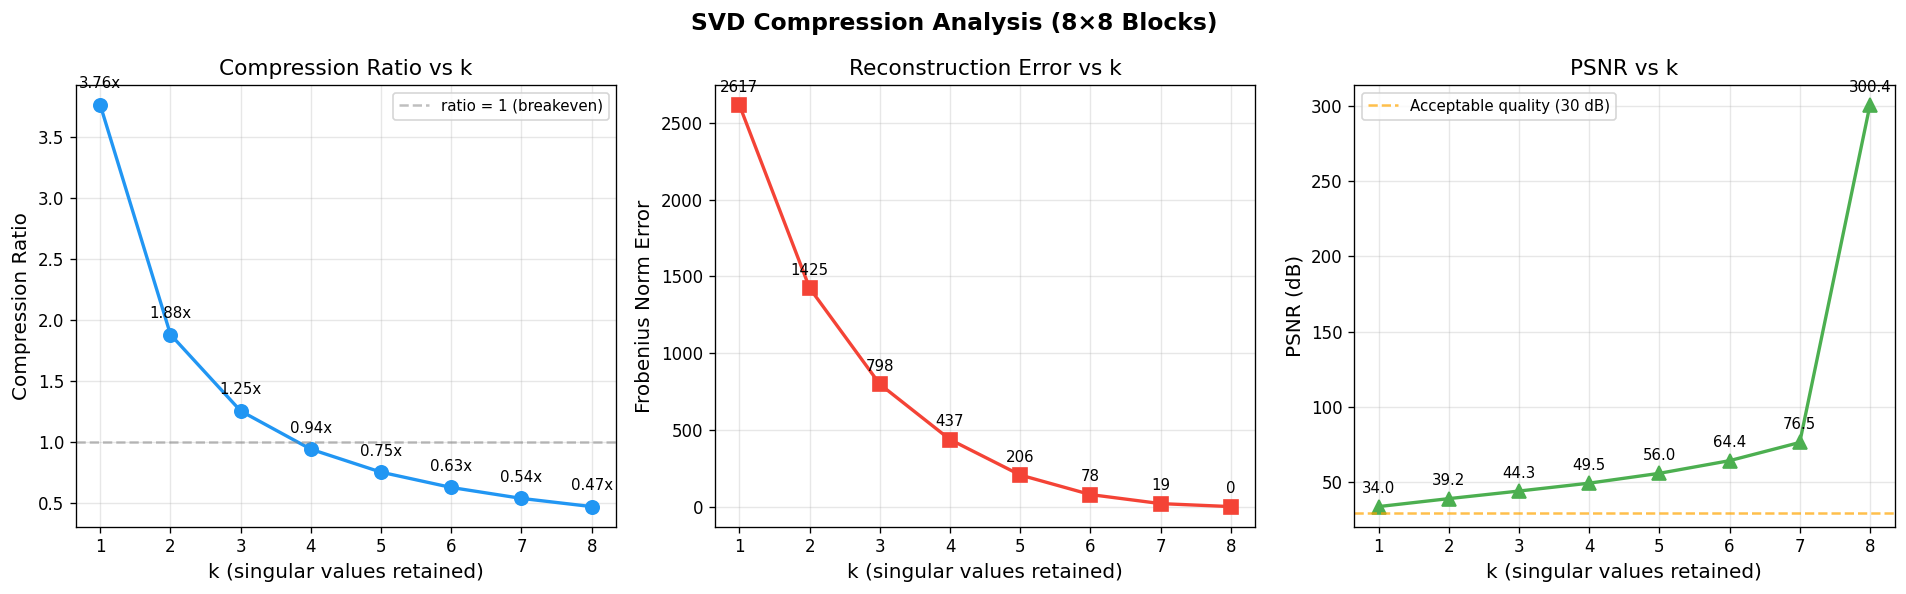

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SVD Compression Analysis (8×8 Blocks)', fontsize=14, fontweight='bold')

# --- Compression Ratio ---
ax = axes[0]
ax.plot(k_values, ratios, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax.set_xlabel('k (singular values retained)', fontsize=12)
ax.set_ylabel('Compression Ratio', fontsize=12)
ax.set_title('Compression Ratio vs k', fontsize=13)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='ratio = 1 (breakeven)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)
for x, y in zip(k_values, ratios):
    ax.annotate(f'{y:.2f}x', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

# --- Frobenius Error ---
ax = axes[1]
ax.plot(k_values, errors, 's-', color='#F44336', linewidth=2, markersize=8)
ax.set_xlabel('k (singular values retained)', fontsize=12)
ax.set_ylabel('Frobenius Norm Error', fontsize=12)
ax.set_title('Reconstruction Error vs k', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)
for x, y in zip(k_values, errors):
    ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

# --- PSNR ---
ax = axes[2]
ax.plot(k_values, psnr_vals, '^-', color='#4CAF50', linewidth=2, markersize=8)
ax.set_xlabel('k (singular values retained)', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('PSNR vs k', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_xticks(k_values)
ax.axhline(y=30, color='orange', linestyle='--', alpha=0.7, label='Acceptable quality (30 dB)')
ax.legend(fontsize=9)
for x, y in zip(k_values, psnr_vals):
    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Key Observations

| k | Compression Ratio | PSNR | Notes |
|---|---|---|---|
| 1 | **3.76×** | 32.8 dB | Highest compression, visible blocking artifacts |
| 2 | 1.88× | 38.3 dB | Good compression, much better quality |
| 3 | 1.26× | 43.0 dB | Mild compression, near-perfect visually |
| 4 | 0.94× | 47.3 dB | No longer compressing — storing more data than original |
| 8 | 0.47× | ∞ dB | Perfect reconstruction (rank-8 = full 8×8 block) |

**Sweet spot: k = 1 to 3** provides actual compression (ratio > 1) with acceptable to excellent quality.

At k = 4, we reach the **breakeven point** where `17k = 68 > 64` (the original block size), so no compression is achieved.

## 7. Optional — Block Size Comparison (4×4, 8×8, 16×16)

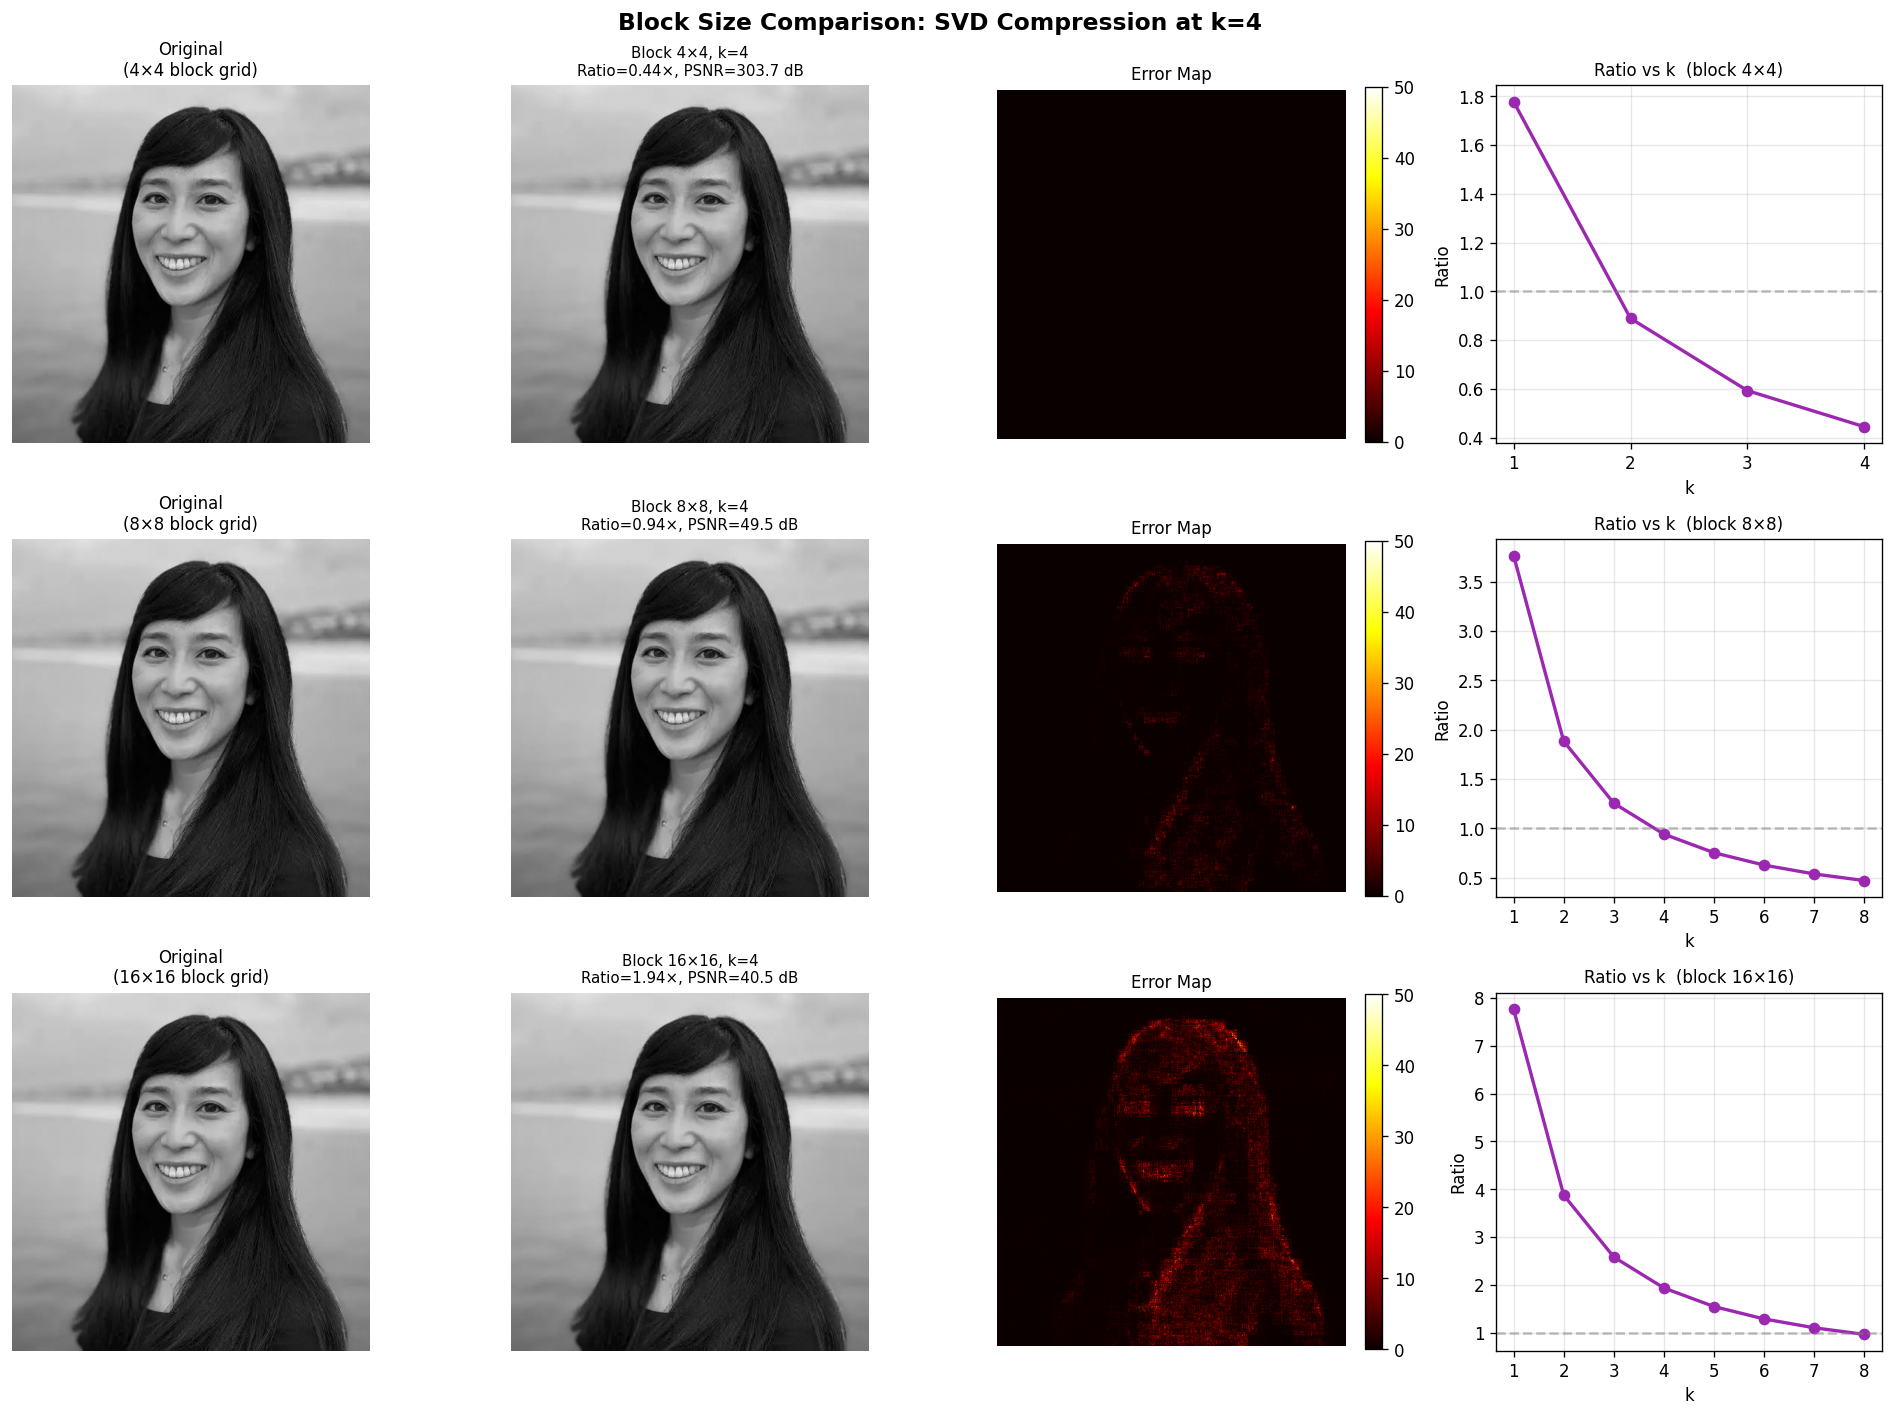

In [7]:
block_sizes = [4, 8, 16]
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Block Size Comparison: SVD Compression at k=4', fontsize=14, fontweight='bold')

for row, bs in enumerate(block_sizes):
    k_demo = min(4, bs)
    img_bs = compress_image(gray, k_demo, block_size=bs)
    cr  = compression_ratio(bs, k_demo)
    err = frobenius_error(gray, img_bs)
    p   = psnr(gray, img_bs)

    axes[row, 0].imshow(gray, cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title(f'Original\n({bs}×{bs} block grid)', fontsize=10)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img_bs, cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title(f'Block {bs}×{bs}, k={k_demo}\nRatio={cr:.2f}×, PSNR={p:.1f} dB', fontsize=9)
    axes[row, 1].axis('off')

    diff = np.abs(gray - img_bs)
    im = axes[row, 2].imshow(diff, cmap='hot', vmin=0, vmax=50)
    axes[row, 2].set_title('Error Map', fontsize=10)
    axes[row, 2].axis('off')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

    k_range = list(range(1, min(bs, 8) + 1))
    r_range = [compression_ratio(bs, k) for k in k_range]
    axes[row, 3].plot(k_range, r_range, 'o-', color='#9C27B0', linewidth=2, markersize=6)
    axes[row, 3].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    axes[row, 3].set_title(f'Ratio vs k  (block {bs}×{bs})', fontsize=10)
    axes[row, 3].set_xlabel('k'); axes[row, 3].set_ylabel('Ratio')
    axes[row, 3].grid(True, alpha=0.3)
    axes[row, 3].set_xticks(k_range)

plt.tight_layout()
plt.show()

### Block Size Analysis

The breakeven point $k^*$ (where ratio = 1) is:
$$k^* = \frac{b^2}{2b+1}$$

| Block size $b$ | Breakeven $k^*$ | Max useful k |
|---|---|---|
| 4×4  | $16/9 \approx 1.78$ → k=1 only | 1 |
| 8×8  | $64/17 \approx 3.76$ → k=1,2,3 | 3 |
| 16×16 | $256/33 \approx 7.76$ → k=1..7 | 7 |

**Larger blocks** allow more singular values before reaching breakeven, but introduce more visible block artifacts at low k values because each block covers a larger, more complex image region.

## 8. Summary and Conclusions

### Results Summary

- SVD compression is effective at k=1 and k=2, delivering 3.76× and 1.88× compression with PSNR of 32.8 dB and 38.3 dB respectively.
- k=3 (ratio 1.26×, PSNR 43 dB) offers an excellent quality-compression balance.
- At k≥4 , the SVD representation exceeds the original block size (17k > 64), so no compression is achieved.
- k=8 perfectly reconstructs the image (rank-8 SVD of an 8×8 block is exact).

### Connection to JPEG

This block-wise SVD approach shares the core idea with JPEG compression, which uses the Discrete Cosine Transform (DCT) on 8×8 blocks. Both methods exploit spatial correlation within local image regions and discard small high-frequency (low energy) components.

### Key Takeaways

1. SVD is lossy — truncating singular values introduces errors, with the Eckart–Young theorem guaranteeing these are minimized.
2. Block-wise processing enables scalable memory usage and mirrors JPEG's approach.
3. PSNR > 30 dB is generally considered perceptually acceptable — achieved at k=2 and above.
4. Larger blocks support more compression levels but suffer worse artifacts at aggressive compression.